In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

import autoates_v2
from ates.models.simple import slope_deg as compute_slope_deg

DATA = (Path(autoates_v2.__file__).parent / "test-data" / "Bow Summit").resolve()
OUTPUTS = DATA / "outputs"

# Bow Summit — Feature Analysis

Bow Summit is the only area with all v2 intermediate rasters pre-computed.
Each raster is flattened to one row per valid pixel, then joined into a single
DataFrame for analysis. Valid pixels are those where the final ATES class is not nodata.




**Question**: Could a convex be detected in MRDEM or HRDEM?

### Glossary & Theory
- **FP**: [FlowPy](https://github.com/avaframe/FlowPy) is a tool to compute gravitational mass flows (GMF) run out and intensity
- **SAT**: Slope Angle Threshold (0-3/4)
  - 3 is ATES v1
  - 4 is for ATES v2
- **AAT**: Alpha Angle Threshold 
- **PRA**: Potential Release Areas. Typically slopes between 30-50°
  - [Veitinger Criteria](https://nhess.copernicus.org/articles/16/2211/2016/nhess-16-2211-2016.pdf):
    - 30-60°
    - Wind-affected
    - Sparsely forested
- **Forest BAV**: Basal Area per Volume ($m^2/ha$). 
  - Cross-sectional of tree trunks at breast height -> how likely the trees are to stop the avie
- **Breast Height**: 1.3m
- **CCI**: Cell Count Criteria (criterion)

#### Alpha Angle
https://github.com/avaframe/FlowPy
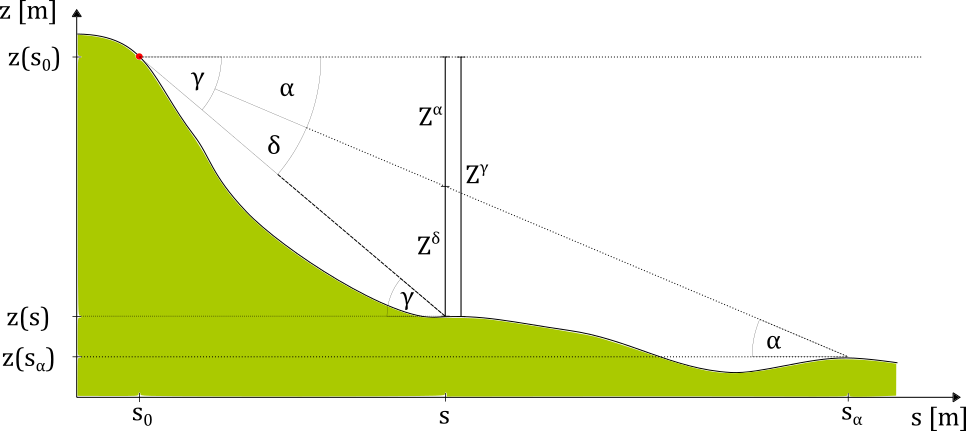
- Big runout = small alpha angle
- FlowPy writes one alpha value per pixel using a [D8 routing algorithm](https://hydrology.usu.edu/taudem/taudem5/help/d8flowdirections.html)
- **This is the feature that separates challenging from simple**: A lot more slopes would be simple if the overhead terrain is not included

#### 

### Initial Thoughts

- The continuous data is being obscured by using classes
- This data could be put to better use in numeric form
- [Pistocchi et al, 2012](https://sci-hub.red/10.1007/s11069-012-0410-3) used a continuous method

### Combine Rasters into DataFrame

Combine individual rasters into DataFrame to facilitate feature extraction

1. `elevation`: vertical distance from sea-level (m)
2. `slope_deg`: angle of the slope (°)
3. `slope_class`: slope classification (0-4)
4. `fp_alpha`: angle between the PRA and to the end of the runout. 
5. `fp_class`: class assigned to alpha angle. (0-3)
6. `overhead_count`: number of upslope cells above a point (no. of pixels)
7. `overhead_class`:
8. `forest_bav`: measure of forested an area is ($m^2/ha$)
9. `forest_class`: forest classification (0-3)
10. `pra_binary`: potential release area: yes or no. (0 | 1) -> very influential feature
11. `ates_v2`: predicted ATES from file

In [2]:
def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    return arr


# Compute continuous slope from the DEM — outputs/slope.tif is the classified version (0–4)
with rasterio.open(DATA / "dem.tif") as src:
    dem_arr = src.read(1).astype(np.float32)
    if src.nodata is not None:
        dem_arr[dem_arr == src.nodata] = np.nan
    res_x, res_y = abs(src.transform.a), abs(src.transform.e)

rasters = {
    "elevation": dem_arr,
    "slope_deg": compute_slope_deg(dem_arr, res_x=res_x, res_y=res_y),
    "slope_class": read_band(OUTPUTS / "slope.tif"),
    "fp_alpha": read_band(DATA / "FP_int16.tif"),
    "fp_class": read_band(OUTPUTS / "flowpy.tif"),
    "overhead_count": read_band(DATA / "Overhead.tif"),
    "overhead_class": read_band(OUTPUTS / "cellcount_reclass.tif"),
    "forest_bav": read_band(DATA / "forest.tif"),
    "forest_class": read_band(OUTPUTS / "forest_reclass.tif"),
    "pra_binary": read_band(DATA / "pra_binary.tif"),
    "ates_v2": read_band(OUTPUTS / "ates_gen.tif"),
}

ates = rasters["ates_v2"]
valid = np.isfinite(ates) & (ates != -9999) & (ates > 0)

df = pd.DataFrame({k: v[valid].astype(np.float32) for k, v in rasters.items()})
df["ates_v2"] = df["ates_v2"].astype(int)

print(df.shape)
df.describe()

(31182, 11)


,elevation,slope_deg,slope_class,fp_alpha,fp_class,overhead_count,overhead_class,forest_bav,forest_class,pra_binary,ates_v2
count,31090.000000,31090.000000,30202.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000,31182.000000
mean,2174.134033,19.652370,1.290775,15.333846,1.677955,15.914085,1.623308,11.813610,19.038548,0.228690,1.852511
std,235.464813,15.710860,1.421551,18.214392,0.836379,20.427622,0.789702,16.418331,13.276068,0.419996,1.040822
min,1831.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,0.000000,1.000000
25%,2003.000000,6.647439,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,10.000000,0.000000,1.000000
50%,2082.000000,16.778273,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,10.000000,0.000000,1.000000
75%,2319.000000,30.073280,3.000000,32.000000,2.000000,36.000000,2.000000,25.000000,40.000000,0.000000,3.000000
max,2954.000000,87.536789,4.000000,70.000000,3.000000,77.000000,3.000000,50.000000,40.000000,1.000000,4.000000


### Exploratory Analysis

Columns with many zeros:

1. `slope_class`: 47.7% (This is classification so probably fine)
2. `fp_alpha`: 56.2%
3. `fp_class`: 56.2% (skewed by fp_alpha)
4. `overhead_count`: 56.7%
5.  `overhead_class`: 57.1%
6.  `forest_bav`: 45.7%
7.  `forest_class`: 65.5%
8.  `pra_binary`: 77.13%


In [3]:
df.ates_v2.value_counts()

ates_v2
1    17334
3     8347
2     3307
4     2194
Name: count, dtype: int64

In [4]:
[{col: float(df[col].value_counts().max() / df.shape[0]) * 100} for col in df.columns]

[{'elevation': 2.2961965236354307},
 {'slope_deg': 3.7265088833301263},
 {'slope_class': 47.719838368289395},
 {'fp_alpha': 56.26322878583798},
 {'fp_class': 56.26322878583798},
 {'overhead_count': 56.75389647873773},
 {'overhead_class': 57.109871079468924},
 {'forest_bav': 45.73471874799564},
 {'forest_class': 65.4672567506895},
 {'pra_binary': 77.1310371368097},
 {'ates_v2': 55.58976332499519}]

<Axes: ylabel='Frequency'>

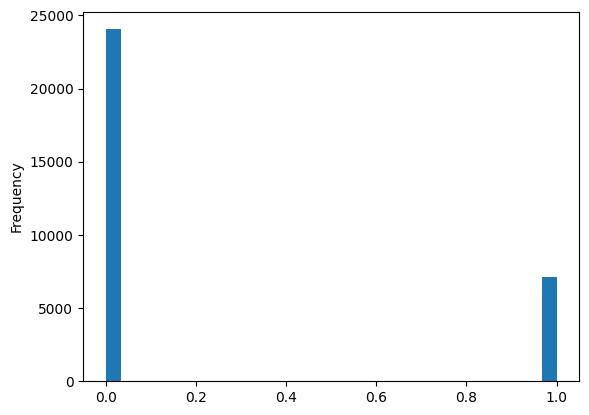

In [5]:
df.pra_binary.plot.hist(bins=30)

In [6]:
sns.violinplot

<function seaborn.categorical.violinplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, inner='box', split=False, width=0.8, dodge='auto', gap=0, linewidth=None, linecolor='auto', cut=2, gridsize=100, bw_method='scott', bw_adjust=1, density_norm='area', common_norm=False, hue_norm=None, formatter=None, log_scale=None, native_scale=False, legend='auto', scale=<deprecated>, scale_hue=<deprecated>, bw=<deprecated>, inner_kws=None, ax=None, **kwargs)>

<Axes: ylabel='pra_binary'>

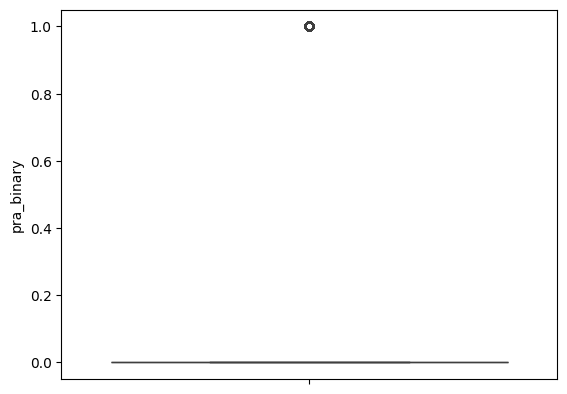

In [7]:
sns.boxplot(data=df, y='pra_binary')

## Feature distributions by ATES class

Three treatment groups:
- **Standard box plot**: `slope_deg`, `elevation` — truly continuous, no zero-inflation
- **log1p box plot**: `fp_alpha`, `overhead_count`, `forest_bav` — zero-heavy but the non-zero distribution matters; log1p preserves zeros at 0 while spreading the tail
- **Proportion bar**: `pra_binary` — show % of pixels per class that are PRA

In [8]:
numeric_cols = ["slope_deg", "elevation"]
zero_heavy_cols = ["fp_alpha", "overhead_count", "forest_bav"]

Normalised Numeric Column Distribution

<Axes: >

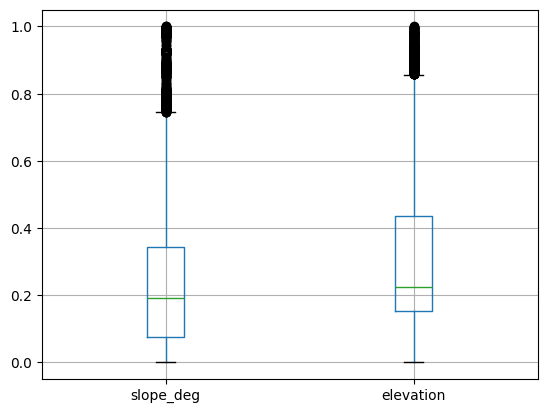

In [9]:
scaled = df.copy()

for column in scaled.columns:
    scaled[column] = (scaled[column] - scaled[column].min()) / (
        scaled[column].max() - scaled[column].min()
    )


scaled.boxplot(column=numeric_cols)

Log1p Dist

<Axes: title={'center': 'Log1p Transformed Box Plot'}>

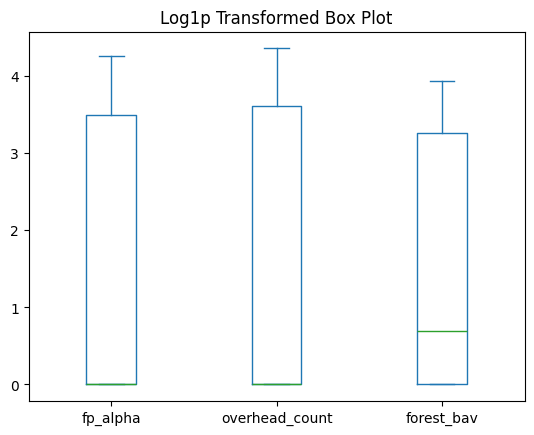

In [10]:
df[zero_heavy_cols].map(np.log1p).plot.box(title='Log1p Transformed Box Plot')

PRA Proportion

<Axes: xlabel='pra_binary', ylabel='Proportion'>

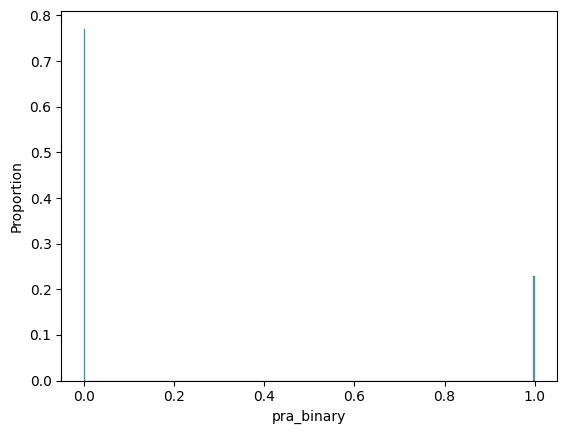

In [11]:
sns.histplot(data=df, x='pra_binary', stat='proportion')

## Spearman Correlation

In [12]:
correlation = df.corr(method='spearman')
correlation

,elevation,slope_deg,slope_class,fp_alpha,fp_class,overhead_count,overhead_class,forest_bav,forest_class,pra_binary,ates_v2
elevation,1.000000,0.667569,0.650841,0.568351,0.561266,0.433405,0.459047,-0.424819,-0.308823,0.519950,0.681186
slope_deg,0.667569,1.000000,0.930650,0.720766,0.703849,0.603967,0.611959,-0.323509,-0.231887,0.672116,0.721869
slope_class,0.650841,0.930650,1.000000,0.778356,0.760099,0.645923,0.655393,-0.442319,-0.351803,0.747509,0.785276
fp_alpha,0.568351,0.720766,0.778356,1.000000,0.986897,0.919023,0.923291,-0.563368,-0.477430,0.675431,0.878545
fp_class,0.561266,0.703849,0.760099,0.986897,1.000000,0.922911,0.928658,-0.557633,-0.477730,0.657264,0.864846
overhead_count,0.433405,0.603967,0.645923,0.919023,0.922911,1.000000,0.985417,-0.507474,-0.451795,0.515716,0.812529
overhead_class,0.459047,0.611959,0.655393,0.923291,0.928658,0.985417,1.000000,-0.518803,-0.456787,0.528175,0.820326
forest_bav,-0.424819,-0.323509,-0.442319,-0.563368,-0.557633,-0.507474,-0.518803,1.000000,0.880027,-0.458324,-0.686147
forest_class,-0.308823,-0.231887,-0.351803,-0.477430,-0.477730,-0.451795,-0.456787,0.880027,1.000000,-0.383163,-0.601531
pra_binary,0.519950,0.672116,0.747509,0.675431,0.657264,0.515716,0.528175,-0.458324,-0.383163,1.000000,0.688784


## v2 Lookup Table — Bow Summit Frequency Annotations

Sum code = `merge_new` (max of slope/fp/cellcount, 1–4) + `forest_reclass` (10/20/30/40) + `SZ_reclass` (0 or 100 for PRA).

Each cell shows **ATES class | pixel count**. Dead rules (zero pixels) are greyed out.

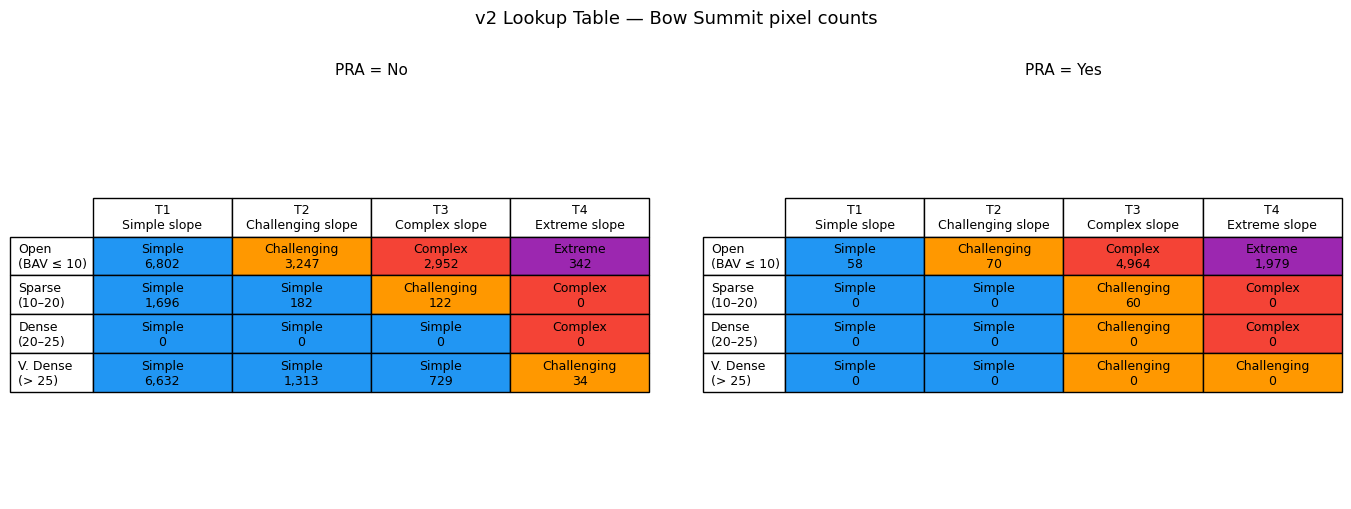

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Hard-coded lookup from AutoATES_classifier.py lines 259-299
LOOKUP = {
    10: 0,
    11: 1,
    12: 2,
    13: 3,
    14: 4,
    20: 0,
    21: 1,
    22: 1,
    23: 2,
    24: 3,
    30: 0,
    31: 1,
    32: 1,
    33: 1,
    34: 3,
    40: 0,
    41: 1,
    42: 1,
    43: 1,
    44: 2,
    110: 0,
    111: 1,
    112: 2,
    113: 3,
    114: 4,
    120: 0,
    121: 1,
    122: 1,
    123: 2,
    124: 3,
    130: 0,
    131: 1,
    132: 1,
    133: 2,
    134: 3,
    140: 0,
    141: 1,
    142: 1,
    143: 2,
    144: 2,
}

# Reconstruct sum codes from intermediate rasters
merge_new = read_band(OUTPUTS / "merge_new.tif")
forest_recls = read_band(OUTPUTS / "forest_reclass.tif")
sz_recls = read_band(OUTPUTS / "SZ_reclass.tif")

sum_raw = merge_new + forest_recls + sz_recls
sum_codes = sum_raw[valid].astype(int)

freq = pd.Series(sum_codes).value_counts()

# Build annotated table: rows = forest class, cols = terrain class, panels = PRA
TERRAIN_LABELS = {
    1: "T1\nSimple slope",
    2: "T2\nChallenging slope",
    3: "T3\nComplex slope",
    4: "T4\nExtreme slope",
}
FOREST_LABELS = {
    10: "Open\n(BAV ≤ 10)",
    20: "Sparse\n(10–20)",
    30: "Dense\n(20–25)",
    40: "V. Dense\n(> 25)",
}
ATES_COLORS = {0: "#cccccc", 1: "#2196F3", 2: "#FF9800", 3: "#F44336", 4: "#9C27B0"}
ATES_NAMES = {0: "–", 1: "Simple", 2: "Challenging", 3: "Complex", 4: "Extreme"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("v2 Lookup Table — Bow Summit pixel counts", fontsize=13, y=1.01)

for ax, pra_offset, pra_label in [
    (axes[0], 0, "PRA = No"),
    (axes[1], 100, "PRA = Yes"),
]:
    terrain_keys = [1, 2, 3, 4]
    forest_keys = [10, 20, 30, 40]

    cell_colors = []
    cell_text = []

    for f in forest_keys:
        row_c, row_t = [], []
        for t in terrain_keys:
            code = pra_offset + f + t
            ates = LOOKUP.get(code, 0)
            count = freq.get(code, 0)
            row_c.append(ATES_COLORS[ates])
            row_t.append(f"{ATES_NAMES[ates]}\n{count:,}")
        cell_colors.append(row_c)
        cell_text.append(row_t)

    ax.axis("off")
    tbl = ax.table(
        cellText=cell_text,
        cellColours=cell_colors,
        rowLabels=list(FOREST_LABELS.values()),
        colLabels=list(TERRAIN_LABELS.values()),
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.4, 2.2)
    ax.set_title(pra_label, fontsize=11, pad=12)

plt.tight_layout()
plt.show()

## Random Forest — Bow Summit pixels

Continuous features only (no class columns). `class_weight='balanced'` to handle the
Simple-heavy imbalance. 80/20 pixel split — analysis only, no generalisation claim.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

FEATURES = ["slope_deg", "fp_alpha", "overhead_count", "forest_bav", "pra_binary"]

rf_df = df[FEATURES + ["ates_v2"]].dropna()
X = rf_df[FEATURES].values
y = rf_df["ates_v2"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
clf.fit(X_train, y_train)

print(
    classification_report(
        y_test,
        clf.predict(X_test),
        target_names=["Simple", "Challenging", "Complex", "Extreme"],
    )
)

              precision    recall  f1-score   support

      Simple       0.99      0.99      0.99      3448
 Challenging       0.88      0.91      0.89       662
     Complex       0.94      0.93      0.93      1669
     Extreme       0.87      0.88      0.87       439

    accuracy                           0.96      6218
   macro avg       0.92      0.93      0.92      6218
weighted avg       0.96      0.96      0.96      6218



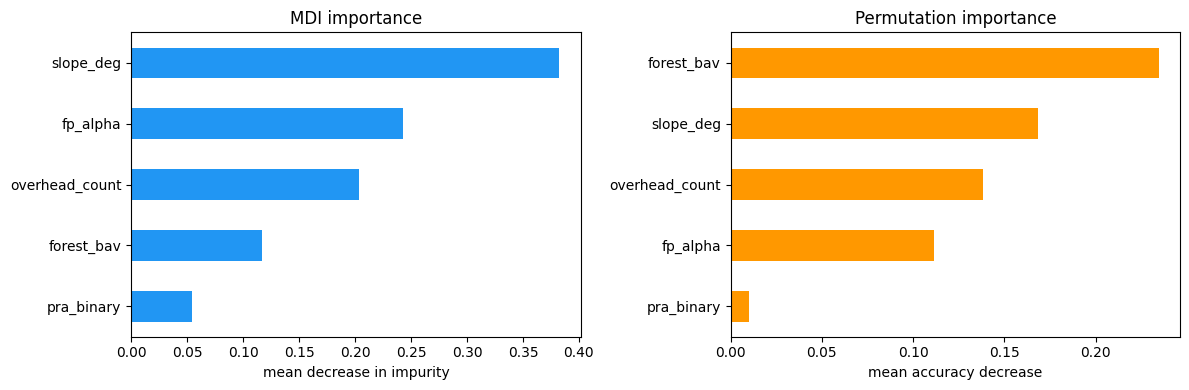

In [15]:
mdi = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()

perm = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_mean = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mdi.plot.barh(ax=axes[0], color="#2196F3")
axes[0].set_title("MDI importance")
axes[0].set_xlabel("mean decrease in impurity")

perm_mean.plot.barh(ax=axes[1], color="#FF9800")
axes[1].set_title("Permutation importance")
axes[1].set_xlabel("mean accuracy decrease")

plt.tight_layout()
plt.show()